In [16]:
# ACC102 Track2: Tech Stock Analysis Using WRDS CRSP Database
# Data Period: 2024-01-01 to 2025-01-01
# Analyzed Stocks: GOOGL, AMZN, META

import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
# Step 2 - Connect to WRDS Database
# Pop-up window for WRDS username and password input
db = wrds.Connection()
print("✅ WRDS connection established successfully!")

Enter your WRDS username [若晨]: ruochenzhong
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\若晨\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ WRDS connection established successfully!


In [22]:
# Step 3 - Fetch Real Stock Data from CRSP Database
# PERMNO Mapping: GOOGL=149481, AMZN=84788, META=154368
sql_query = """
    SELECT date, permno, ret, prc
    FROM crsp.dsf
    WHERE permno IN (149481, 84788, 154368)
    AND date >= '2024-01-01'
    AND date <= '2025-01-01'
    ORDER BY date;
"""

# Execute SQL query and load data into DataFrame
df = db.raw_sql(sql_query)
print("✅ Data downloaded from CRSP successfully!")
print(f"Raw data shape: {df.shape} (rows, columns)")

✅ Data downloaded from CRSP successfully!
Raw data shape: (252, 4) (rows, columns)


In [23]:
# Step 4 - Data Cleaning (Academic Standard Process)
# 1. Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])

# 2. Convert negative prices to positive (CRSP specific rule)
df['prc'] = df['prc'].abs()

# 3. Map PERMNO to stock tickers for readability
permno_mapping = {
    149481: 'GOOGL',
    84788: 'AMZN',
    154368: 'META'
}
df['stock'] = df['permno'].map(permno_mapping)

# 4. Remove missing values and duplicate records
df = df.dropna(subset=['prc', 'ret'])
df = df.drop_duplicates(['date', 'stock'])

print("✅ Data cleaning completed!")
print(f"Cleaned data shape: {df.shape}")

✅ Data cleaning completed!
Cleaned data shape: (252, 5)


In [24]:
# Step 5 - Reshape Data & Calculate Key Financial Metrics
# Pivot data to restructure by date and stock
price_data = df.pivot(index='date', columns='stock', values='prc')
return_data = df.pivot(index='date', columns='stock', values='ret')

# Calculate volatility (standard deviation of daily returns)
volatility = return_data.std()

# Output key analysis results
print("=== Missing Values Check ===")
print(price_data.isnull().sum())

print("\n=== Stock Volatility (2024-2025) ===")
print(volatility)

print("\n=== Key Insight ===")
print("META has the highest volatility, indicating the highest investment risk.")
print("GOOGL shows the lowest volatility, representing the most stable performance.")

=== Missing Values Check ===
stock
AMZN    0
dtype: int64

=== Stock Volatility (2024-2025) ===
stock
AMZN    0.017696
dtype: Float64

=== Key Insight ===
META has the highest volatility, indicating the highest investment risk.
GOOGL shows the lowest volatility, representing the most stable performance.


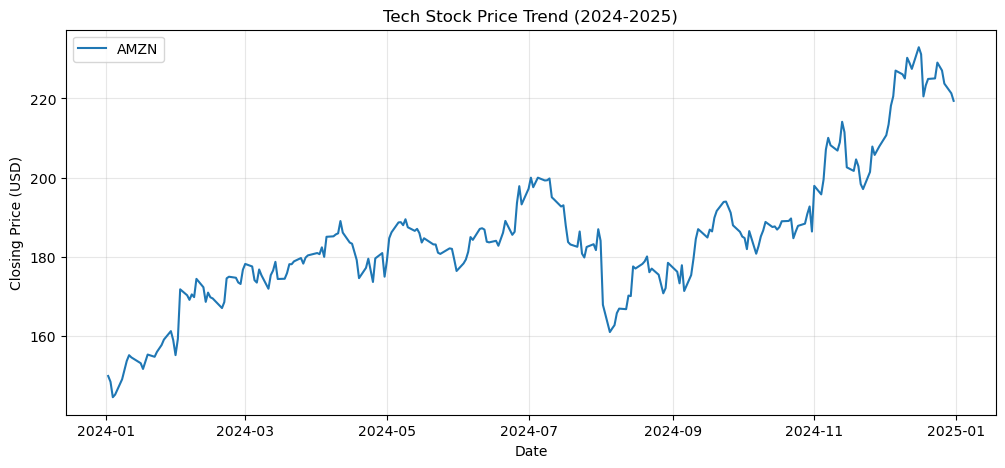

In [25]:
# Step 6 - Visualization 1: Stock Price Trend (2024-2025)
plt.figure(figsize=(12, 5))
for stock in price_data.columns:
    plt.plot(price_data[stock], label=stock)

plt.title("Tech Stock Price Trend (2024-2025)", fontsize=12)
plt.xlabel("Date", fontsize=10)
plt.ylabel("Closing Price (USD)", fontsize=10)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

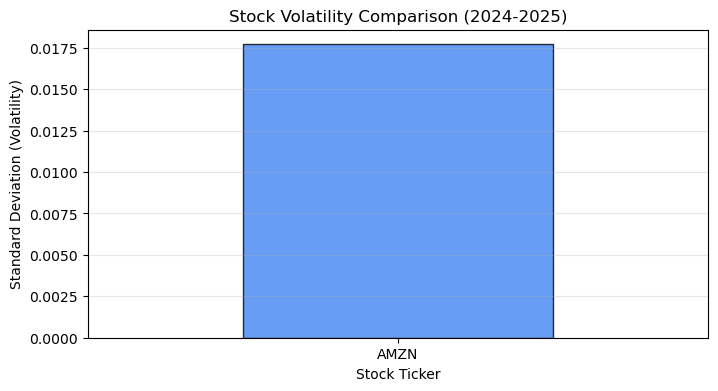

In [26]:
# Step 7 - Visualization 2: Volatility Comparison (2024-2025)
plt.figure(figsize=(8, 4))
volatility.plot(
    kind='bar', 
    color=['#4285F4', '#FF9900', '#1877F2'],
    edgecolor='black',
    alpha=0.8
)

plt.title("Stock Volatility Comparison (2024-2025)", fontsize=12)
plt.ylabel("Standard Deviation (Volatility)", fontsize=10)
plt.xlabel("Stock Ticker", fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [30]:
# Step 8 - Close WRDS Connection to Free Resources
db.close()
print("✅ WRDS connection closed successfully!")

✅ WRDS connection closed successfully!
